# Sentence Memorability Experiment
<!-- ## **Exploratory Data Analysis** -->

<!-- **Task:** Participants read sentences presented sequentially. When a sentence carries the same *meaning* as a previously seen one, they press **spacebar** (Information Recognition, IR). They then indicate whether it is *word-for-word identical* by pressing **'a' (Yes)** or **'d' (No)** (Word Recognition, WR). -->

<!-- **Stimulus Categories:**
| Code | Description |
|------|-------------|
| HF   | High Frequency (common words) |
| HH   | High imageability, High frequency |
| HVL  | High Valence, Low frequency |
| LVH  | Low Valence, High frequency |
| LVL  | Low Valence, Low frequency | -->

## **Experimental Details**

Participants viewed a **continuous stream of sentences**, presented one at a time on the screen.
Two recognition judgments were embedded within the same trial sequence:

* **Information Recognition (IR):**
  Participants pressed the **spacebar** when a sentence conveyed the **same meaning as a sentence shown earlier**, regardless of whether the wording was identical or paraphrased.
  This measure captures **gist-level memory**.

* **Word Recognition (WR):**
  After pressing the spacebar, participants indicated whether the sentence was **exactly the same as the earlier one** by pressing **'A' (Yes)** or **'D' (No)**.
  This measure captures **verbatim memory**.

* **First Presentations:**
  For sentences appearing **for the first time**, participants **did not press the spacebar**, as no prior sentence existed for recognition.



## **Background and Context**

Human memory for language does not store sentences word-for-word. Cognitive psychology distinguishes between **gist memory** (remembering the meaning) and **verbatim memory** (remembering the exact wording).
This experiment investigates both using a **continuous recognition task**, where participants identify repeated sentences that appear either **with identical wording** or as **paraphrases with the same meaning**.

We also examine how **stimulus characteristics influence memorability**. Sentences are grouped into categories based on **word frequency (High/Low)** and **emotional valence or imageability (High/Low)**. This allows us to test whether sentences containing **common, emotional, or concrete words** are remembered better than those with **rare or neutral words**.

## **Research Hypothesis**
**H1 — Lexical Frequency Facilitates Semantic Recognition**

Sentences composed of **high-frequency lexical items** (HF, HH, LVH categories) are expected to produce **higher Information Recognition (IR) hit rates and faster IR reaction times** compared to sentences from **low-frequency categories** (HVL, LVL).
This hypothesis reflects the assumption that **frequent or familiar words are processed more efficiently and encoded more robustly in memory**, facilitating faster and more accurate detection of repeated meanings.

**H2 — Partial Independence of Gist and Verbatim Memory**

Although **gist memory (IR)** and **verbatim memory (WR)** are expected to be positively related, the relationship should be **moderate rather than perfect**, reflecting the cognitive distinction between **semantic encoding and surface-form encoding**.
Accordingly, sentences with higher **IR memorability scores** should tend to show **higher WR accuracy**, but substantial variability is expected, indicating that **recognizing meaning does not necessarily imply accurate recall of exact wording**.


---


## **Planned Analysis**

#### Overview

We test two main hypotheses examining how **lexical properties influence semantic recognition** and how **gist memory relates to verbatim memory**. Analyses combine **descriptive statistics, visualizations, and inferential tests**.

---

#### **H1 — Lexical Frequency Facilitates Semantic Recognition**

**Prediction**

Sentences from **high-frequency categories (HF, HH, LVH)** will show:

* **Higher IR hit rates**
* **Faster IR reaction times**

compared to **low-frequency categories (HVL, LVL)**.

**Analysis**

* Compute **IR hit rate and reaction time** per category
* Compare categories using **repeated-measures ANOVA (hit rate)** and **mixed-effects models (RT)**
* Examine **SDT sensitivity (d′)** as a complementary measure

**Visualizations**

* d′ by category
* Reaction time distributions

**Support for H1**

H1 is supported if **high-frequency categories show higher sensitivity and faster reaction times** than low-frequency categories.

---

#### **H2 — Partial Independence of Gist and Verbatim Memory**

**Prediction**

Sentences with **higher IR memorability** will generally show **higher WR accuracy**, but the relationship will be **moderate rather than perfect**, reflecting the distinction between **semantic (gist) and surface (verbatim) memory**.

**Analysis**

* Compute **sentence-level IR memorability** and **WR accuracy**
* Test relationship using **Pearson and Spearman correlations**
* Fit regression models to assess whether the relationship varies across categories

**Visualizations**

* IR–WR scatter plot with regression
* WR confusion matrix
* WR accuracy by category

**Support for H2**

H2 is supported if **IR and WR are positively correlated but show substantial independent variance**.

---

<!-- #### Multiple Comparison Control

* **Primary hypothesis tests:** α = .05
* **Pairwise comparisons:** Bonferroni correction applied
* **Effect sizes** reported (η², Cohen’s d, R²) -->


## 0 · Data Loading & Preprocessing

In [69]:
import pandas as pd
import numpy as np
import os

data_folder = "data"

def parse_stimulus(stim):
    parts = stim.split("_")
    return parts[0], parts[1], parts[2]

def process_log(file_path):
    df = pd.read_csv(file_path)
    participant_id = df["participant_ID"].iloc[0]
    seen_meaning = set()
    seen_exact = set()
    trials = []
    current_trial = None

    for _, row in df.iterrows():
        event = row["Event"]
        stim = row["Stimulus"]

        if pd.isna(stim) and event != "gap_time":
            continue

        if event == "Sentence shown":
            category, sid, version = parse_stimulus(stim)
            semantic_repeat = (category, sid) in seen_meaning
            exact_repeat    = stim in seen_exact
            current_trial = {
                "participant":    participant_id,
                "stimulus":       stim,
                "category":       category,
                "sentence_id":    sid,
                "version":        version,
                "semantic_repeat": semantic_repeat,
                "exact_repeat":   exact_repeat,
                "ir_pressed":     False,
                "wr_response":    None,
                "rt_ir":          None,
                "rt_wr":          None
            }
            seen_meaning.add((category, sid))
            seen_exact.add(stim)

        elif event == "IR pressed" and current_trial:
            current_trial["ir_pressed"] = True
            current_trial["rt_ir"] = row["Reaction_time_IR"]

        elif event == "WR pressed" and current_trial:
            current_trial["wr_response"] = row["Button"]
            current_trial["rt_wr"] = row["Reaction_time_WR"]

        elif event == "gap_time" and current_trial:
            trials.append(current_trial)
            current_trial = None

    return pd.DataFrame(trials)


all_trials = []
for file in os.listdir(data_folder):
    if file.endswith(".log"):
        path = os.path.join(data_folder, file)
        all_trials.append(process_log(path))

trial_df = pd.concat(all_trials, ignore_index=True)
print(f"Loaded {len(trial_df):,} trials from {trial_df['participant'].nunique()} participants")
trial_df.head()

Loaded 25,308 trials from 114 participants


,participant,stimulus,category,sentence_id,version,semantic_repeat,exact_repeat,ir_pressed,wr_response,rt_ir,rt_wr
0,256,HF_9_A,HF,9,A,False,False,False,NaN,NaN,NaN
1,256,HVL_118_P,HVL,118,P,False,False,False,NaN,NaN,NaN
2,256,HF_9_A,HF,9,A,True,True,True,Yes,2481.0,3133.0
3,256,HVL_102_A,HVL,102,A,False,False,False,NaN,NaN,NaN
4,256,HF_27_A,HF,27,A,False,False,False,NaN,NaN,NaN


In [70]:
# ---------- Signal-detection outcome labels ----------
def classify(row):
    if row.semantic_repeat and row.ir_pressed:      return "Hit"
    if row.semantic_repeat and not row.ir_pressed:  return "Miss"
    if not row.semantic_repeat and row.ir_pressed:  return "False Alarm"
    return "Correct Reject"

trial_df["outcome"] = trial_df.apply(classify, axis=1)

# ---------- Sentence memorability score ----------
mem_score = (
    trial_df.groupby(["category", "sentence_id"])["outcome"]
    .apply(lambda x: (x == "Hit").sum() / max((x == "Hit").sum() + (x == "Miss").sum(), 1))
    .reset_index(name="memorability")
)

# ---------- WR sub-dataset ----------
wr_df = trial_df[trial_df["wr_response"].notna()].copy()

def wr_correct(row):
    if row["exact_repeat"] and row["wr_response"] == "Yes":  return 1
    if not row["exact_repeat"] and row["wr_response"] == "No": return 1
    return 0

wr_df["wr_correct"] = wr_df.apply(wr_correct, axis=1)

# ---------- Trial index for learning-curve ----------
trial_df["trial_index"] = trial_df.groupby("participant").cumcount()

print("Outcome distribution (proportion):")
print(trial_df["outcome"].value_counts(normalize=True).round(3))

Outcome distribution (proportion):
outcome
Correct Reject    0.566
Hit               0.307
False Alarm       0.082
Miss              0.044
Name: proportion, dtype: float64


## 1 · Visual Style Setup

In [71]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Professional colour palette ────────────────────────────────────────────────
CAT_PALETTE  = {"HF": "#4C72B0", "HH": "#DD8452", "HVL": "#55A868",
                "LVH": "#C44E52", "LVL": "#8172B2"}
OUT_PALETTE  = {"Hit": "#2ecc71", "Miss": "#e74c3c",
                "False Alarm": "#f39c12", "Correct Reject": "#3498db"}
BLUE         = "#4C72B0"
GREY         = "#7f8c8d"
FONT_TITLE   = {"fontsize": 14, "fontweight": "bold", "pad": 12}
FONT_LABEL   = {"fontsize": 11}

# ── Global rcParams ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        130,
    "figure.facecolor":  "white",
    "axes.facecolor":    "#f8f9fa",
    "axes.edgecolor":    "#cccccc",
    "axes.linewidth":    0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "white",
    "grid.linewidth":    1.0,
    "font.family":       "DejaVu Sans",
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
})

CATS = ["HF", "HH", "HVL", "LVH", "LVL"]
print("Style configured.")

Style configured.


---
## 2 · Overall Behavioral Performance

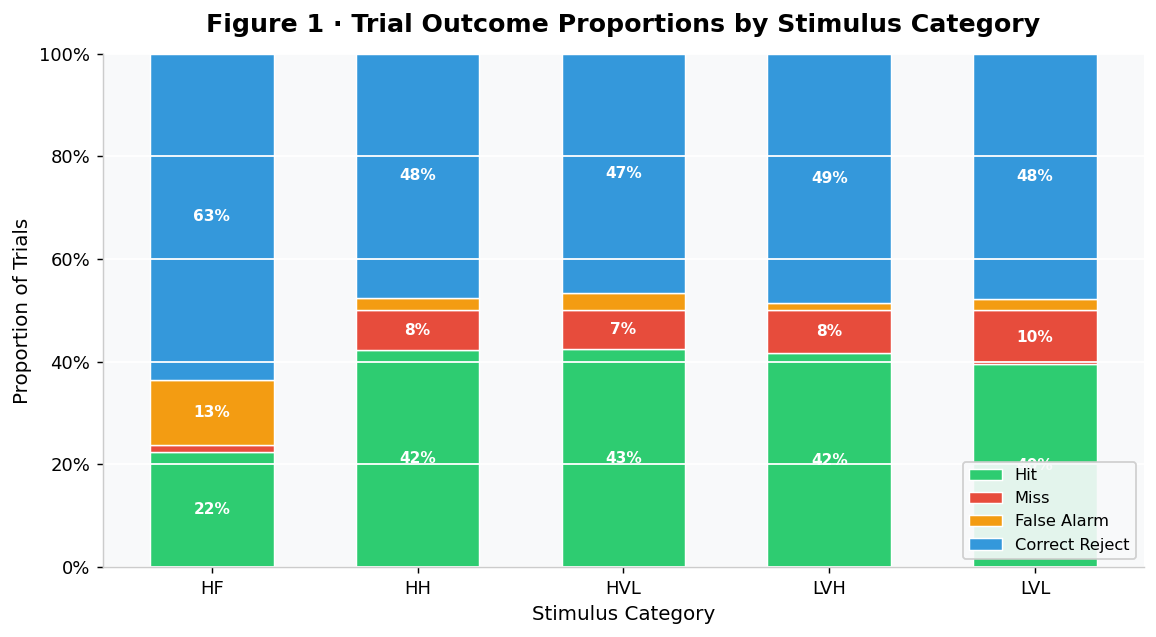

In [72]:
# ── Figure 1: Outcome proportions by category (grouped 100%-stacked bar) ──────
order = ["Hit", "Miss", "False Alarm", "Correct Reject"]

cat_prop = (
    trial_df.groupby(["category", "outcome"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=order)
    .apply(lambda r: r / r.sum(), axis=1)   # proportions
    .reindex(CATS)
)

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(CATS))
x = np.arange(len(CATS))

for outcome in order:
    vals = cat_prop[outcome].values
    bars = ax.bar(x, vals, bottom=bottom, color=OUT_PALETTE[outcome],
                  label=outcome, width=0.6, edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, vals):
        if v > 0.04:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f"{v:.0%}", ha="center", va="center",
                    fontsize=8.5, color="white", fontweight="bold")
    bottom += vals

ax.set_xticks(x); ax.set_xticklabels(CATS)
ax.set_xlabel("Stimulus Category", **FONT_LABEL)
ax.set_ylabel("Proportion of Trials", **FONT_LABEL)
ax.set_title("Figure 1 · Trial Outcome Proportions by Stimulus Category", **FONT_TITLE)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.0%}"))
ax.legend(loc="lower right", framealpha=0.9, fontsize=9)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig("fig1_outcome_proportions.png", bbox_inches="tight")
plt.show()

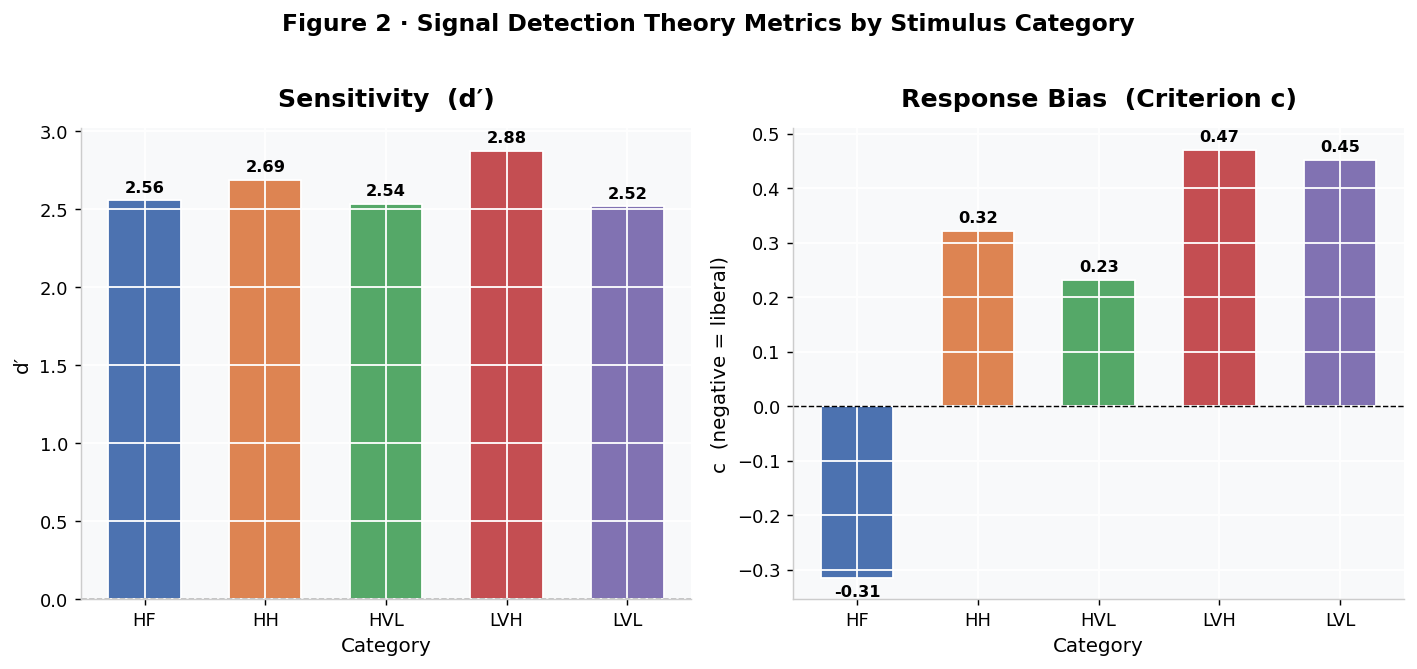


SDT summary table:
          hit_rate  fa_rate  d_prime  criterion
category                                       
HF           0.945    0.167    2.560     -0.315
HH           0.847    0.048    2.690      0.321
HVL          0.850    0.067    2.536      0.232
LVH          0.833    0.028    2.876      0.471
LVL          0.791    0.043    2.521      0.451


In [73]:
# ── Figure 2: Signal Detection Theory metrics (d-prime & criterion c) ─────────
from scipy.stats import norm

def sdt_metrics(sub):
    """Compute d-prime and criterion c for one group."""
    hit_r = sub["outcome"].eq("Hit").sum() / max(sub["outcome"].isin(["Hit","Miss"]).sum(), 1)
    fa_r  = sub["outcome"].eq("False Alarm").sum() / max(sub["outcome"].isin(["False Alarm","Correct Reject"]).sum(), 1)
    # Loglinear correction to avoid z(0) or z(1)
    n_sig = sub["outcome"].isin(["Hit","Miss"]).sum()
    n_nos = sub["outcome"].isin(["False Alarm","Correct Reject"]).sum()
    hit_r_c = (sub["outcome"].eq("Hit").sum() + 0.5) / (n_sig + 1)
    fa_r_c  = (sub["outcome"].eq("False Alarm").sum() + 0.5) / (n_nos + 1)
    zh, zf  = norm.ppf(hit_r_c), norm.ppf(fa_r_c)
    return pd.Series({"hit_rate": hit_r, "fa_rate": fa_r, "d_prime": zh - zf, "criterion": -0.5*(zh+zf)})

sdt = trial_df.groupby("category").apply(sdt_metrics).reindex(CATS)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
colors = [CAT_PALETTE[c] for c in CATS]

# d-prime
axes[0].bar(CATS, sdt["d_prime"], color=colors, edgecolor="white", width=0.6)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
for i, (cat, v) in enumerate(zip(CATS, sdt["d_prime"])):
    axes[0].text(i, v + 0.03, f"{v:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_title("Sensitivity  (d′)", **FONT_TITLE)
axes[0].set_xlabel("Category", **FONT_LABEL)
axes[0].set_ylabel("d′", **FONT_LABEL)
axes[0].set_ylim(0)

# criterion c
axes[1].bar(CATS, sdt["criterion"], color=colors, edgecolor="white", width=0.6)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
for i, (cat, v) in enumerate(zip(CATS, sdt["criterion"])):
    yoff = 0.01 if v >= 0 else -0.04
    axes[1].text(i, v + yoff, f"{v:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[1].set_title("Response Bias  (Criterion c)", **FONT_TITLE)
axes[1].set_xlabel("Category", **FONT_LABEL)
axes[1].set_ylabel("c  (negative = liberal)", **FONT_LABEL)

fig.suptitle("Figure 2 · Signal Detection Theory Metrics by Stimulus Category",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig2_sdt_metrics.png", bbox_inches="tight")
plt.show()

print("\nSDT summary table:")
print(sdt.round(3))

---
## 3 · Memorability Analysis

In [74]:
# # ── Figure 3: Memorability distribution by category (violin + box + jitter) ───
# fig, ax = plt.subplots(figsize=(10, 5.5))

# parts = ax.violinplot(
#     [mem_score[mem_score.category == c]["memorability"].dropna() for c in CATS],
#     positions=range(len(CATS)), widths=0.7, showmedians=False, showextrema=False
# )
# for pc, cat in zip(parts["bodies"], CATS):
#     pc.set_facecolor(CAT_PALETTE[cat]); pc.set_alpha(0.45); pc.set_edgecolor("grey")

# # Overlay boxplot
# bp = ax.boxplot(
#     [mem_score[mem_score.category == c]["memorability"].dropna() for c in CATS],
#     positions=range(len(CATS)), widths=0.12,
#     patch_artist=True, medianprops=dict(color="black", linewidth=2),
#     boxprops=dict(facecolor="white", alpha=0.9),
#     whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1),
#     flierprops=dict(marker="o", markersize=3, alpha=0.3)
# )

# # Jitter
# rng = np.random.default_rng(42)
# for i, cat in enumerate(CATS):
#     y = mem_score[mem_score.category == cat]["memorability"].dropna()
#     x = rng.normal(i, 0.06, size=len(y))
#     ax.scatter(x, y, s=18, alpha=0.55, color=CAT_PALETTE[cat], zorder=3)

# ax.set_xticks(range(len(CATS))); ax.set_xticklabels(CATS)
# ax.set_xlabel("Stimulus Category", **FONT_LABEL)
# ax.set_ylabel("Memorability Score (Hit Rate per Sentence)", **FONT_LABEL)
# ax.set_title("Figure 3 · Sentence Memorability Distribution by Category", **FONT_TITLE)
# ax.set_ylim(0.4, 1.05)
# ax.axhline(mem_score["memorability"].mean(), color=GREY, linewidth=1.2,
#            linestyle="--", label=f"Grand mean = {mem_score['memorability'].mean():.2f}")
# ax.legend(fontsize=9)
# plt.tight_layout()
# plt.savefig("fig3_memorability_violin.png", bbox_inches="tight")
# plt.show()

In [75]:
# # ── Figure 4: Participant-level hit rate vs. false alarm rate (ROC scatter) ────
# per_ppt = trial_df.groupby("participant").apply(sdt_metrics).reset_index()

# fig, ax = plt.subplots(figsize=(7, 6))

# sc = ax.scatter(
#     per_ppt["fa_rate"], per_ppt["hit_rate"],
#     c=per_ppt["d_prime"], cmap="plasma", s=60, alpha=0.8,
#     edgecolors="white", linewidths=0.5, zorder=3
# )

# # chance diagonal
# ax.plot([0, 1], [0, 1], color=GREY, linewidth=1, linestyle="--", label="Chance")

# cbar = fig.colorbar(sc, ax=ax, pad=0.01)
# cbar.set_label("d′", fontsize=10)

# ax.set_xlabel("False Alarm Rate", **FONT_LABEL)
# ax.set_ylabel("Hit Rate", **FONT_LABEL)
# ax.set_title("Figure 4 · Participant-Level ROC Plot\n(colour = sensitivity d′)", **FONT_TITLE)
# ax.set_xlim(0, 1); ax.set_ylim(0, 1)
# ax.legend(fontsize=9)
# plt.tight_layout()
# plt.savefig("fig4_roc_scatter.png", bbox_inches="tight")
# plt.show()

# print(f"Participant d′: M = {per_ppt['d_prime'].mean():.2f}, SD = {per_ppt['d_prime'].std():.2f}")

---
## 4 · Reaction Time Analyses

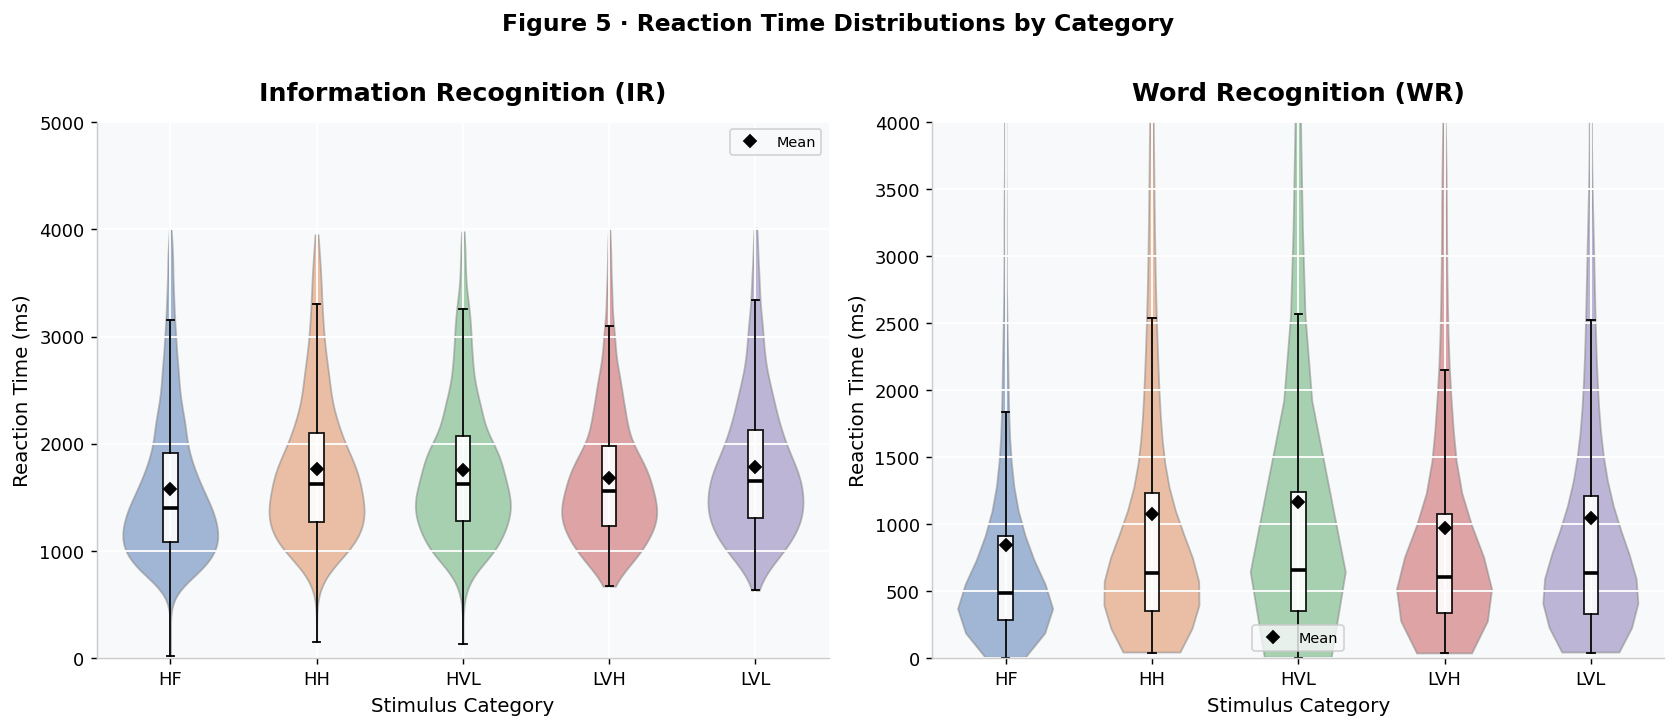

In [76]:
# ── Figure 5: RT violin for IR and WR side-by-side ────────────────────────────
ir_data = trial_df.dropna(subset=["rt_ir"])
wr_data = wr_df.dropna(subset=["rt_wr"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=False)

for ax, data, rt_col, task, ylim in [
    (axes[0], ir_data, "rt_ir", "Information Recognition (IR)", (0, 5000)),
    (axes[1], wr_data, "rt_wr", "Word Recognition (WR)",       (0, 4000)),
]:
    parts = ax.violinplot(
        [data[data.category == c][rt_col].dropna() for c in CATS],
        positions=range(len(CATS)), widths=0.65,
        showmedians=False, showextrema=False
    )
    for pc, cat in zip(parts["bodies"], CATS):
        pc.set_facecolor(CAT_PALETTE[cat]); pc.set_alpha(0.5); pc.set_edgecolor("grey")

    ax.boxplot(
        [data[data.category == c][rt_col].dropna() for c in CATS],
        positions=range(len(CATS)), widths=0.1,
        patch_artist=True, medianprops=dict(color="black", linewidth=2),
        boxprops=dict(facecolor="white", alpha=0.9),
        whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1),
        flierprops=dict(visible=False)
    )
    means = [data[data.category == c][rt_col].mean() for c in CATS]
    ax.plot(range(len(CATS)), means, "D", color="black", ms=5, zorder=5, label="Mean")

    ax.set_xticks(range(len(CATS))); ax.set_xticklabels(CATS)
    ax.set_xlabel("Stimulus Category", **FONT_LABEL)
    ax.set_ylabel("Reaction Time (ms)", **FONT_LABEL)
    ax.set_title(task, **FONT_TITLE)
    ax.set_ylim(ylim)
    ax.legend(fontsize=8)

fig.suptitle("Figure 5 · Reaction Time Distributions by Category",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig5_rt_violins.png", bbox_inches="tight")
plt.show()

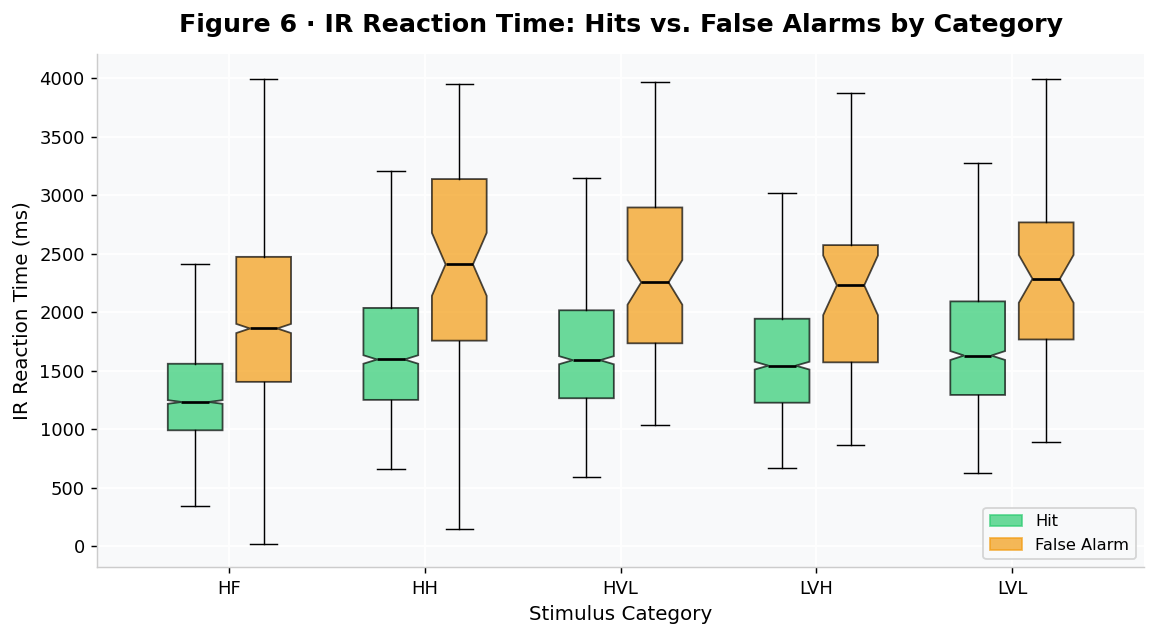

In [77]:
# ── Figure 6: IR reaction time by outcome type (Hit vs. False Alarm) ──────────
ir_outcomes = trial_df[trial_df["outcome"].isin(["Hit", "False Alarm"]) & trial_df["rt_ir"].notna()].copy()

fig, ax = plt.subplots(figsize=(9, 5))

for i, cat in enumerate(CATS):
    for j, outcome in enumerate(["Hit", "False Alarm"]):
        sub = ir_outcomes[(ir_outcomes.category == cat) & (ir_outcomes.outcome == outcome)]["rt_ir"].dropna()
        if len(sub) < 5: continue
        x = i + (j - 0.5) * 0.35
        bp = ax.boxplot(sub, positions=[x], widths=0.28,
                        patch_artist=True, notch=True,
                        medianprops=dict(color="black", linewidth=1.5),
                        boxprops=dict(facecolor=OUT_PALETTE[outcome], alpha=0.7),
                        whiskerprops=dict(linewidth=0.8), capprops=dict(linewidth=0.8),
                        flierprops=dict(visible=False))

ax.set_xticks(range(len(CATS))); ax.set_xticklabels(CATS)
ax.set_xlabel("Stimulus Category", **FONT_LABEL)
ax.set_ylabel("IR Reaction Time (ms)", **FONT_LABEL)
ax.set_title("Figure 6 · IR Reaction Time: Hits vs. False Alarms by Category", **FONT_TITLE)

patches = [mpatches.Patch(color=OUT_PALETTE[o], alpha=0.7, label=o) for o in ["Hit", "False Alarm"]]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig("fig6_rt_outcome.png", bbox_inches="tight")
plt.show()

---
## 5 · Word Recognition (Exact Memory)

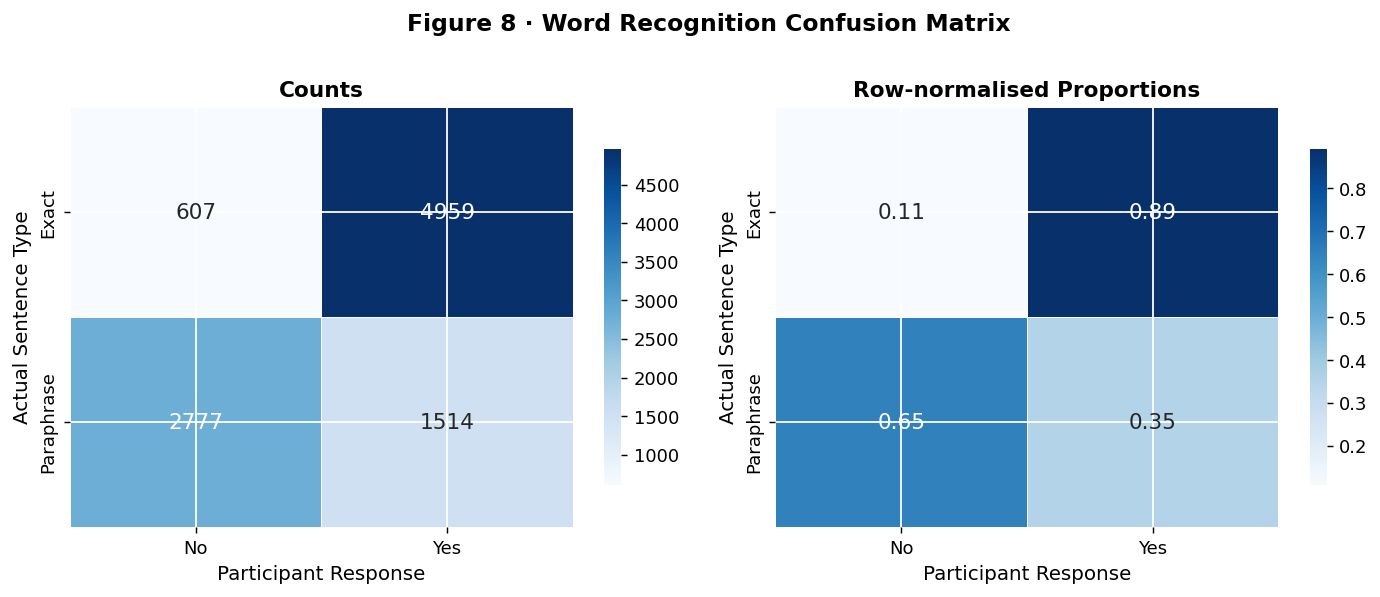

In [79]:
# ── Figure 8: WR confusion matrix (normalised by row) ─────────────────────────
wr_df["actual"]    = wr_df["exact_repeat"].map({True: "Exact", False: "Paraphrase"})
wr_df["predicted"] = wr_df["wr_response"]

raw    = pd.crosstab(wr_df["actual"], wr_df["predicted"])
normed = raw.div(raw.sum(axis=1), axis=0)   # row normalised

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, data, fmt, title in [
    (axes[0], raw,    "d",    "Counts"),
    (axes[1], normed, ".2f", "Row-normalised Proportions"),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                linewidths=0.5, ax=ax,
                cbar_kws={"shrink": 0.8},
                annot_kws={"fontsize": 12})
    ax.set_ylabel("Actual Sentence Type", **FONT_LABEL)
    ax.set_xlabel("Participant Response", **FONT_LABEL)
    ax.set_title(title, fontsize=12, fontweight="bold")

fig.suptitle("Figure 8 · Word Recognition Confusion Matrix",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig8_confusion_matrix.png", bbox_inches="tight")
plt.show()

---
## 6 · Learning Effects & Individual Differences

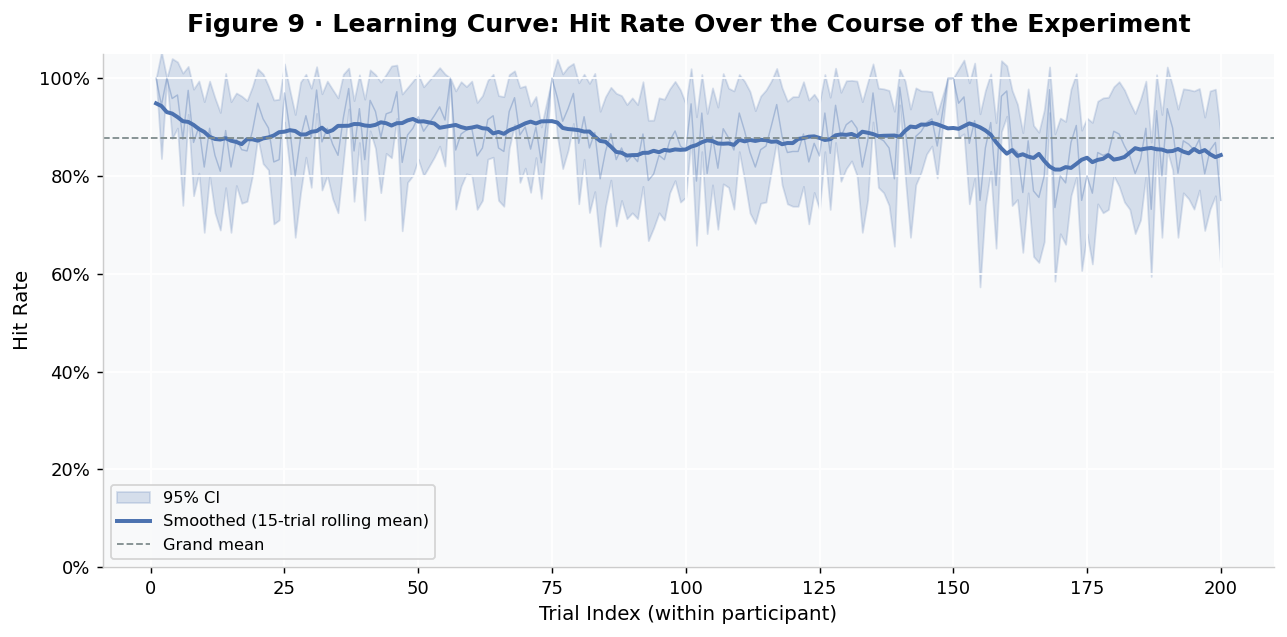

In [80]:
# ── Figure 9: Learning curve with smoothing and confidence band ───────────────
learning_raw = (
    trial_df[trial_df.outcome.isin(["Hit","Miss"])]
    .groupby(["participant", "trial_index"])["outcome"]
    .apply(lambda x: (x=="Hit").mean())
    .reset_index(name="hit")
)

agg = learning_raw.groupby("trial_index")["hit"].agg(["mean","sem"]).reset_index()
agg = agg[agg["trial_index"] <= 200]  # first 200 trials

# Rolling smooth
window = 15
agg["smooth"] = agg["mean"].rolling(window, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(agg["trial_index"],
                agg["mean"] - 1.96 * agg["sem"],
                agg["mean"] + 1.96 * agg["sem"],
                alpha=0.2, color=BLUE, label="95% CI")
ax.plot(agg["trial_index"], agg["mean"],  color=BLUE, alpha=0.35, linewidth=0.8)
ax.plot(agg["trial_index"], agg["smooth"], color=BLUE, linewidth=2.2, label=f"Smoothed ({window}-trial rolling mean)")
ax.axhline(agg["mean"].mean(), color=GREY, linestyle="--", linewidth=1, label="Grand mean")

ax.set_xlabel("Trial Index (within participant)", **FONT_LABEL)
ax.set_ylabel("Hit Rate", **FONT_LABEL)
ax.set_title("Figure 9 · Learning Curve: Hit Rate Over the Course of the Experiment", **FONT_TITLE)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.0%}"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig9_learning_curve.png", bbox_inches="tight")
plt.show()

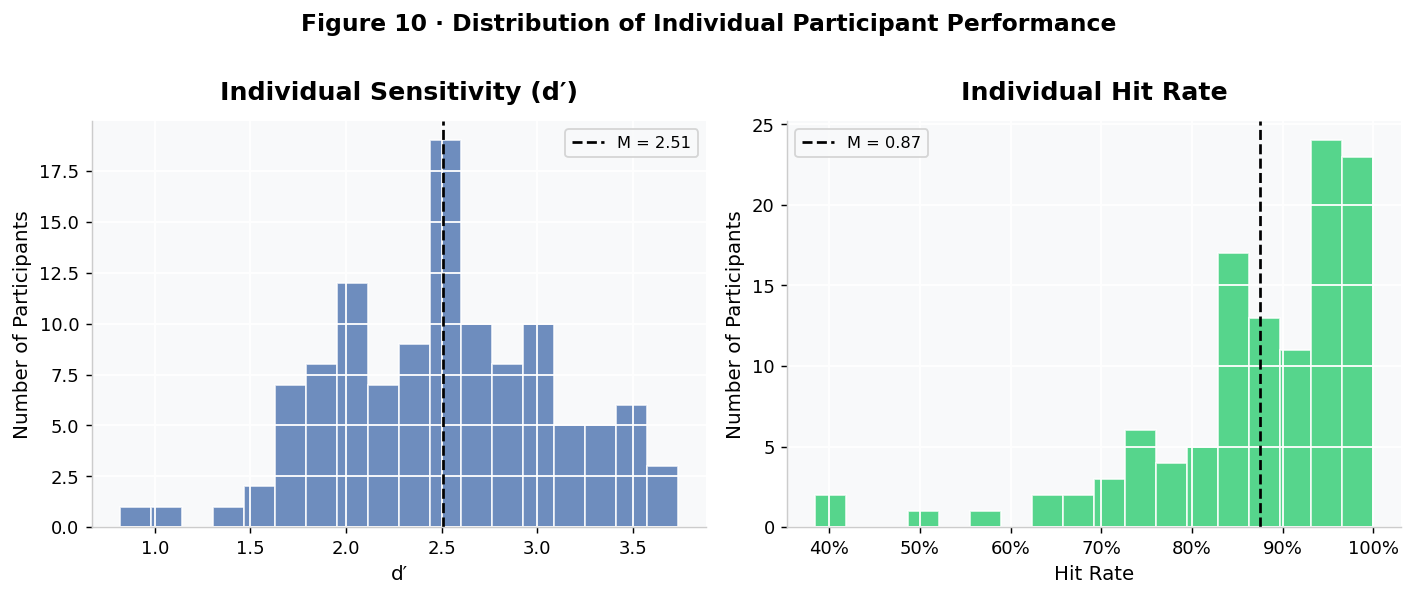

In [81]:
# ── Figure 10: Distribution of participant-level d-prime ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# d-prime distribution
ax = axes[0]
ax.hist(per_ppt["d_prime"].dropna(), bins=18, color=BLUE, alpha=0.8, edgecolor="white")
ax.axvline(per_ppt["d_prime"].mean(), color="black", linewidth=1.5,
           linestyle="--", label=f"M = {per_ppt['d_prime'].mean():.2f}")
ax.set_xlabel("d′", **FONT_LABEL)
ax.set_ylabel("Number of Participants", **FONT_LABEL)
ax.set_title("Individual Sensitivity (d′)", **FONT_TITLE)
ax.legend(fontsize=9)

# Hit rate distribution
ax = axes[1]
ax.hist(per_ppt["hit_rate"].dropna(), bins=18, color=OUT_PALETTE["Hit"], alpha=0.8, edgecolor="white")
ax.axvline(per_ppt["hit_rate"].mean(), color="black", linewidth=1.5,
           linestyle="--", label=f"M = {per_ppt['hit_rate'].mean():.2f}")
ax.set_xlabel("Hit Rate", **FONT_LABEL)
ax.set_ylabel("Number of Participants", **FONT_LABEL)
ax.set_title("Individual Hit Rate", **FONT_TITLE)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.0%}"))
ax.legend(fontsize=9)

fig.suptitle("Figure 10 · Distribution of Individual Participant Performance",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig10_participant_distributions.png", bbox_inches="tight")
plt.show()

---
## 7 · Summary Statistics Table

In [82]:
# ── Summary table: key metrics per category ───────────────────────────────────
summary = pd.DataFrame(index=CATS)

for cat in CATS:
    sub = trial_df[trial_df.category == cat]
    oc  = sub["outcome"].value_counts(normalize=True)
    summary.loc[cat, "Hit Rate"]       = round(oc.get("Hit", 0), 3)
    summary.loc[cat, "False Alarm Rate"] = round(oc.get("False Alarm", 0), 3)
    summary.loc[cat, "d′"]             = round(sdt.loc[cat, "d_prime"], 3)
    summary.loc[cat, "Criterion c"]    = round(sdt.loc[cat, "criterion"], 3)
    summary.loc[cat, "Mean RT-IR (ms)"] = round(sub["rt_ir"].mean(), 1)
    summary.loc[cat, "Mean RT-WR (ms)"] = round(sub["rt_wr"].mean(), 1)
    summary.loc[cat, "Memorability"]   = round(
        mem_score[mem_score.category == cat]["memorability"].mean(), 3)
    wr_sub = wr_df[wr_df.category == cat]
    summary.loc[cat, "WR Accuracy"]    = round(wr_sub["wr_correct"].mean(), 3)

display(summary.style
    .background_gradient(cmap="Blues", subset=["Hit Rate", "d′", "Memorability", "WR Accuracy"])
    .background_gradient(cmap="Oranges", subset=["False Alarm Rate"])
    .format(precision=3)
    .set_caption("Table 1 · Per-Category Performance Summary")
)

,Hit Rate,False Alarm Rate,d′,Criterion c,Mean RT-IR (ms),Mean RT-WR (ms),Memorability,WR Accuracy
HF,0.225,0.127,2.560,-0.315,1580.000,841.400,0.945,0.816
HH,0.424,0.024,2.690,0.321,1763.700,1077.600,0.850,0.754
HVL,0.425,0.033,2.536,0.232,1756.400,1162.800,0.847,0.750
LVH,0.417,0.014,2.876,0.471,1680.300,972.000,0.834,0.769
LVL,0.395,0.022,2.521,0.451,1785.900,1045.500,0.794,0.735


---
## 8 · Category-Wise Multi-Metric Comparison

> **Goal:** Which stimulus category produces the best overall memorability?

We compare every category simultaneously across five key metrics using a **Spider / Radar Chart** and a **Radial Heat Map**, then use a **Mosaic Plot** to show the raw proportional breakdown of all four trial outcomes.


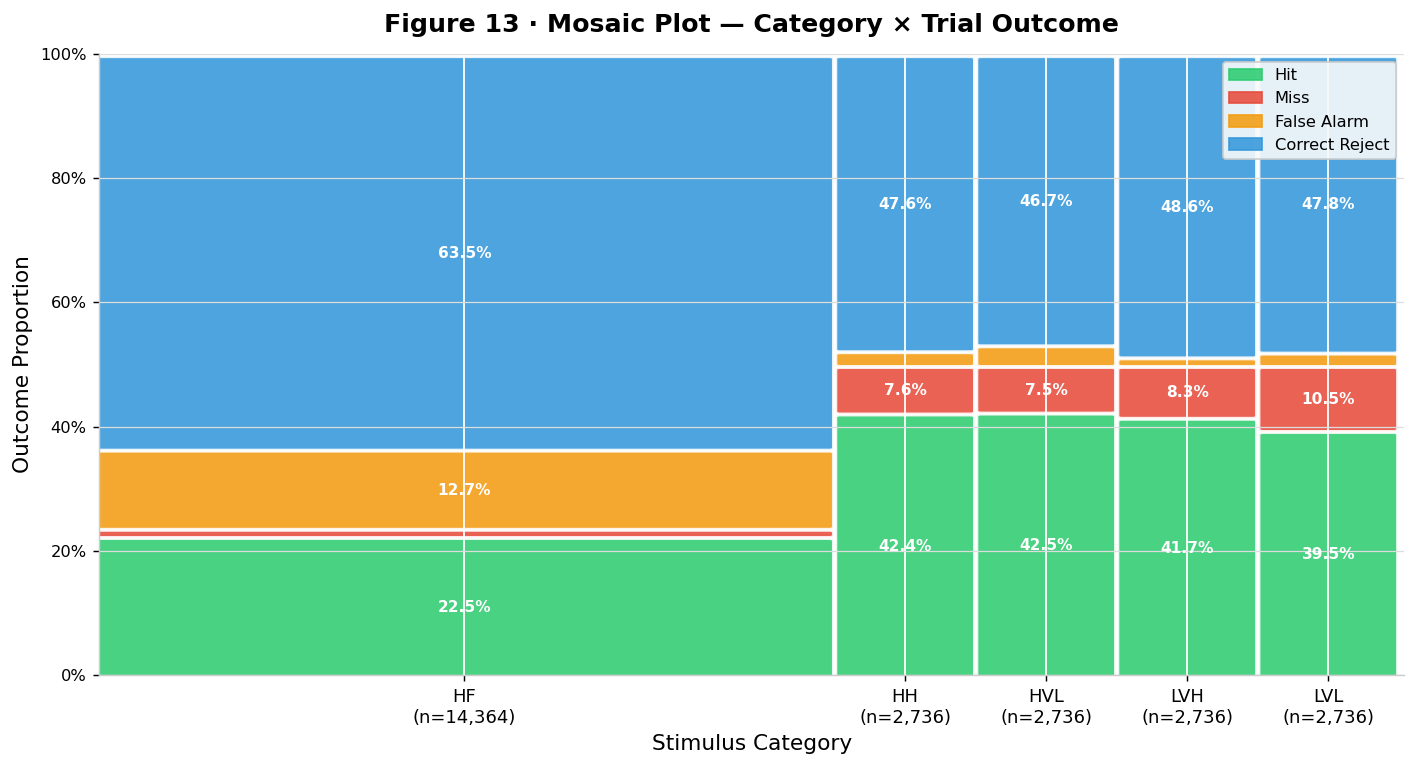

In [85]:

# ── Figure 13 · Mosaic Plot — Category × Outcome breakdown ────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

order_out = ["Hit", "Miss", "False Alarm", "Correct Reject"]

# proportions matrix: rows=CATS, cols=outcomes
cat_prop_mat = (
    trial_df.groupby(["category","outcome"]).size()
    .unstack(fill_value=0)
    .reindex(index=CATS, columns=order_out)
)
cat_counts  = cat_prop_mat.sum(axis=1)
cat_weights = cat_counts / cat_counts.sum()   # relative width of each column

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_facecolor("white"); fig.patch.set_facecolor("white")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Stimulus Category", fontsize=12)
ax.set_ylabel("Outcome Proportion", fontsize=12)
ax.set_title("Figure 13 · Mosaic Plot — Category × Trial Outcome", fontsize=14, fontweight="bold", pad=12)

gap = 0.008
x_cursor = 0.0
xtick_pos, xtick_lab = [], []

for ci, cat in enumerate(CATS):
    col_w = cat_weights.iloc[ci] - gap
    props  = cat_prop_mat.loc[cat] / cat_prop_mat.loc[cat].sum()
    y_cursor = 0.0
    for oi, outcome in enumerate(order_out):
        h = props[outcome]
        rect = mpatches.FancyBboxPatch(
            (x_cursor, y_cursor), col_w, h - gap,
            boxstyle="round,pad=0.003",
            facecolor=OUT_PALETTE[outcome], edgecolor="white",
            linewidth=1.5, alpha=0.88
        )
        ax.add_patch(rect)
        if h > 0.06:
            ax.text(x_cursor + col_w/2, y_cursor + (h-gap)/2,
                    f"{h:.1%}", ha="center", va="center",
                    fontsize=8.5, color="white", fontweight="bold")
        y_cursor += h

    xtick_pos.append(x_cursor + col_w/2)
    xtick_lab.append(f"{cat}\n(n={cat_counts.iloc[ci]:,})")
    x_cursor += cat_weights.iloc[ci]

ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_lab, fontsize=10)
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels([f"{v:.0%}" for v in np.linspace(0, 1, 6)], fontsize=9)
ax.grid(axis="y", color="#dddddd", linewidth=0.7)

legend_patches = [mpatches.Patch(color=OUT_PALETTE[o], alpha=0.88, label=o) for o in order_out]
ax.legend(handles=legend_patches, loc="upper right", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig("fig13_mosaic_plot.png", bbox_inches="tight")
plt.show()


---
## 9 · Word Recognition Accuracy — "Was it Exactly the Same?"

> **Goal:** How accurately did participants identify whether a repeated sentence was *word-for-word identical*? We analyse this overall (combined), per category, and per sentence version.


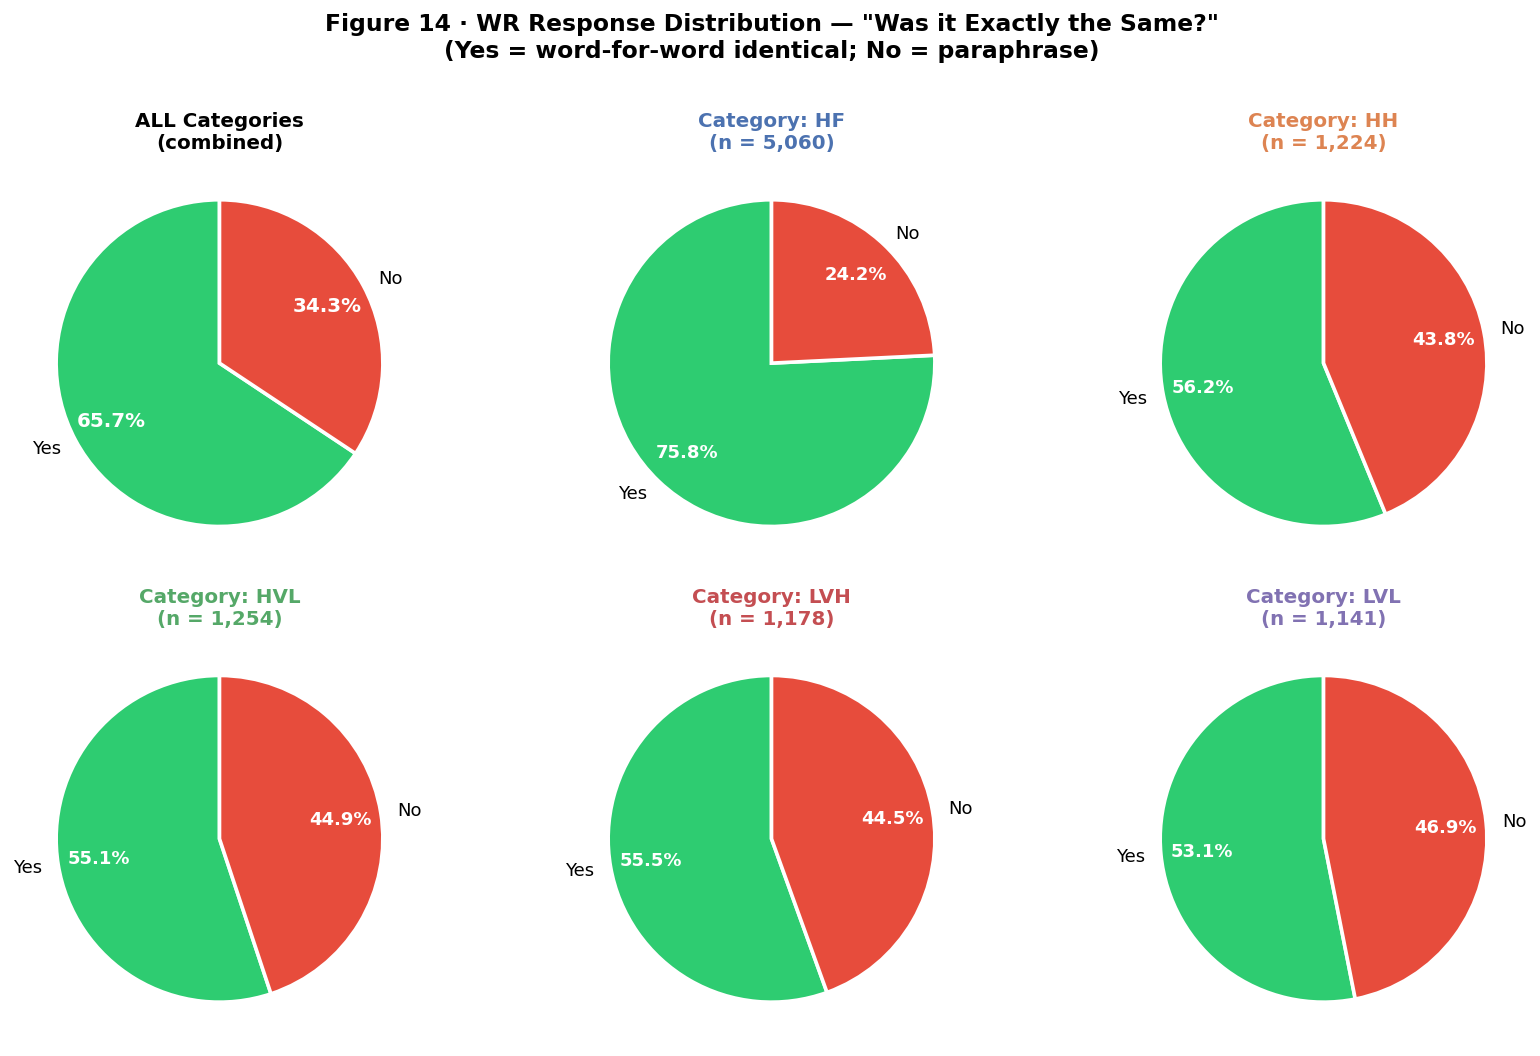

In [86]:

# ── Figure 14 · Pie Charts — WR response distribution by category ──────────
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

pie_colors = {"Yes": "#2ecc71", "No": "#e74c3c"}

# Overall pie (first panel)
ax = axes[0]
overall_counts = wr_df["wr_response"].value_counts()
wedges, texts, autotexts = ax.pie(
    overall_counts.values,
    labels=overall_counts.index,
    autopct="%1.1f%%",
    colors=[pie_colors.get(k, GREY) for k in overall_counts.index],
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight("bold"); at.set_color("white")
ax.set_title("ALL Categories\n(combined)", fontsize=11, fontweight="bold")

# Per-category pies
for i, cat in enumerate(CATS):
    ax = axes[i + 1]
    sub = wr_df[wr_df.category == cat]["wr_response"].value_counts()
    wedges, texts, autotexts = ax.pie(
        sub.values,
        labels=sub.index,
        autopct="%1.1f%%",
        colors=[pie_colors.get(k, GREY) for k in sub.index],
        startangle=90, pctdistance=0.75,
        wedgeprops=dict(edgecolor="white", linewidth=2)
    )
    for at in autotexts:
        at.set_fontsize(10); at.set_fontweight("bold"); at.set_color("white")
    n = len(wr_df[wr_df.category == cat])
    ax.set_title(f"Category: {cat}\n(n = {n:,})", fontsize=11, fontweight="bold",
                 color=CAT_PALETTE[cat])

fig.suptitle('Figure 14 · WR Response Distribution — "Was it Exactly the Same?"\n(Yes = word-for-word identical; No = paraphrase)',
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig14_pie_wr_responses.png", bbox_inches="tight")
plt.show()


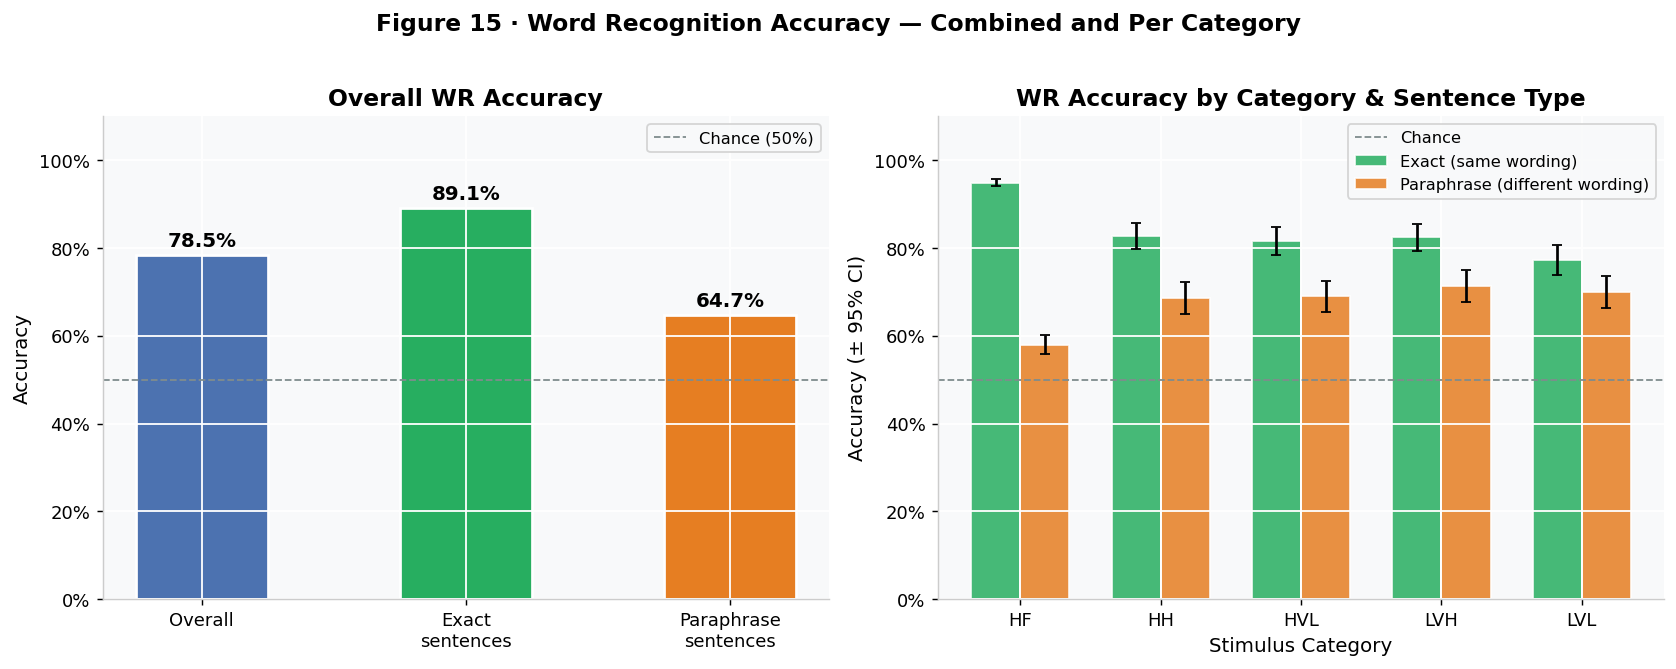

In [87]:

# ── Figure 15 · Bar Chart — WR accuracy: overall + by category + by exact/para ─
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Overall accuracy bar
ax = axes[0]
overall_acc = wr_df["wr_correct"].mean()
exact_acc   = wr_df[wr_df.exact_repeat]["wr_correct"].mean()
para_acc    = wr_df[~wr_df.exact_repeat]["wr_correct"].mean()

labels = ["Overall", "Exact\nsentences", "Paraphrase\nsentences"]
vals   = [overall_acc, exact_acc, para_acc]
colors = ["#4C72B0", "#27ae60", "#e67e22"]
bars = ax.bar(labels, vals, color=colors, width=0.5, edgecolor="white", linewidth=1.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
            f"{v:.1%}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.axhline(0.5, color=GREY, linestyle="--", linewidth=1, label="Chance (50%)")
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.0%}"))
ax.set_title("Overall WR Accuracy", fontsize=13, fontweight="bold")
ax.set_ylabel("Accuracy", fontsize=11)
ax.legend(fontsize=9)

# Right: Per-category grouped (exact vs paraphrase)
ax = axes[1]
x = np.arange(len(CATS))
w = 0.35
exact_accs = [wr_df[(wr_df.category==c) &  wr_df.exact_repeat]["wr_correct"].mean() for c in CATS]
para_accs  = [wr_df[(wr_df.category==c) & ~wr_df.exact_repeat]["wr_correct"].mean() for c in CATS]
exact_se   = [wr_df[(wr_df.category==c) &  wr_df.exact_repeat]["wr_correct"].sem()  for c in CATS]
para_se    = [wr_df[(wr_df.category==c) & ~wr_df.exact_repeat]["wr_correct"].sem()  for c in CATS]

b1 = ax.bar(x - w/2, exact_accs, w, color="#27ae60", alpha=0.85, label="Exact (same wording)", edgecolor="white")
b2 = ax.bar(x + w/2, para_accs,  w, color="#e67e22", alpha=0.85, label="Paraphrase (different wording)", edgecolor="white")
ax.errorbar(x - w/2, exact_accs, yerr=np.array(exact_se)*1.96, fmt="none", color="black", capsize=3)
ax.errorbar(x + w/2, para_accs,  yerr=np.array(para_se) *1.96, fmt="none", color="black", capsize=3)

ax.axhline(0.5, color=GREY, linestyle="--", linewidth=1, label="Chance")
ax.set_xticks(x); ax.set_xticklabels(CATS)
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.0%}"))
ax.set_title("WR Accuracy by Category & Sentence Type", fontsize=13, fontweight="bold")
ax.set_xlabel("Stimulus Category", fontsize=11)
ax.set_ylabel("Accuracy (± 95% CI)", fontsize=11)
ax.legend(fontsize=9)

fig.suptitle("Figure 15 · Word Recognition Accuracy — Combined and Per Category",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig15_wr_accuracy_bars.png", bbox_inches="tight")
plt.show()


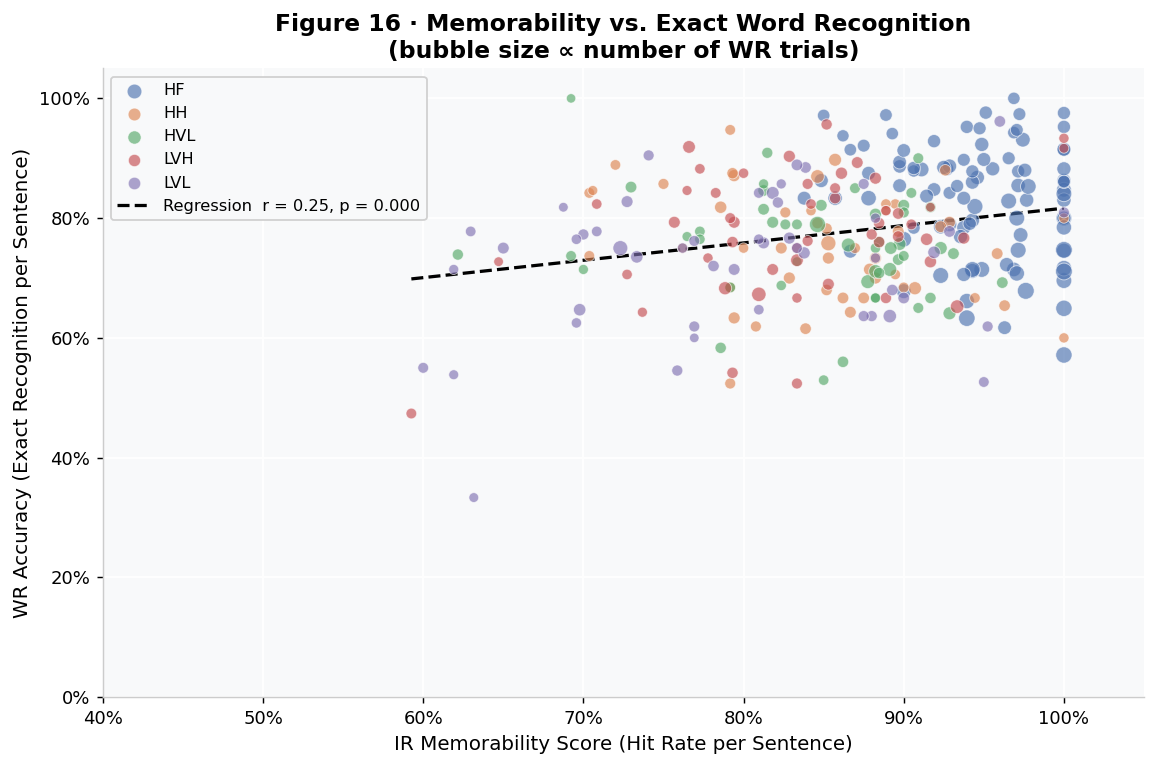

Pearson r = 0.249, p = 0.0000  (n = 292 sentences)


In [88]:

# ── Figure 16 · Scatter Plot — Sentence Memorability vs. WR Accuracy ──────
wr_sentence_acc = (
    wr_df.groupby(["category","sentence_id"])["wr_correct"]
    .agg(["mean","count"])
    .reset_index()
    .rename(columns={"mean":"wr_acc","count":"n_wr"})
)
merged = mem_score.merge(wr_sentence_acc, on=["category","sentence_id"], how="inner")

fig, ax = plt.subplots(figsize=(9, 6))

for cat in CATS:
    sub = merged[merged.category == cat]
    ax.scatter(sub["memorability"], sub["wr_acc"],
               s=sub["n_wr"] * 0.8 + 20,   # size = number of WR trials
               color=CAT_PALETTE[cat], alpha=0.65, edgecolors="white",
               linewidths=0.5, label=cat, zorder=3)

# Regression line (all pooled)
from scipy.stats import pearsonr, linregress
xv = merged["memorability"].values
yv = merged["wr_acc"].values
mask = ~(np.isnan(xv) | np.isnan(yv))
slope, intercept, r, p, _ = linregress(xv[mask], yv[mask])
x_line = np.linspace(xv[mask].min(), xv[mask].max(), 100)
ax.plot(x_line, slope*x_line + intercept, color="black", linewidth=1.8, linestyle="--",
        label=f"Regression  r = {r:.2f}, p = {p:.3f}")

ax.set_xlabel("IR Memorability Score (Hit Rate per Sentence)", fontsize=11)
ax.set_ylabel("WR Accuracy (Exact Recognition per Sentence)", fontsize=11)
ax.set_title("Figure 16 · Memorability vs. Exact Word Recognition\n(bubble size ∝ number of WR trials)",
             fontsize=13, fontweight="bold")
ax.set_xlim(0.4, 1.05); ax.set_ylim(0, 1.05)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.0%}"))
ax.legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig("fig16_scatter_mem_vs_wr.png", bbox_inches="tight")
plt.show()

print(f"Pearson r = {r:.3f}, p = {p:.4f}  (n = {mask.sum()} sentences)")


---
## 10 · Raindrop & Distribution Deep-Dives

> **Goal:** Inspect the full distribution of individual sentences and participants using **Raindrop plots** (beeswarm-style), **Box-Plots** and **Histograms** together, to show every single data point — not just summaries.


Rows after dropping NaN d-prime: 570


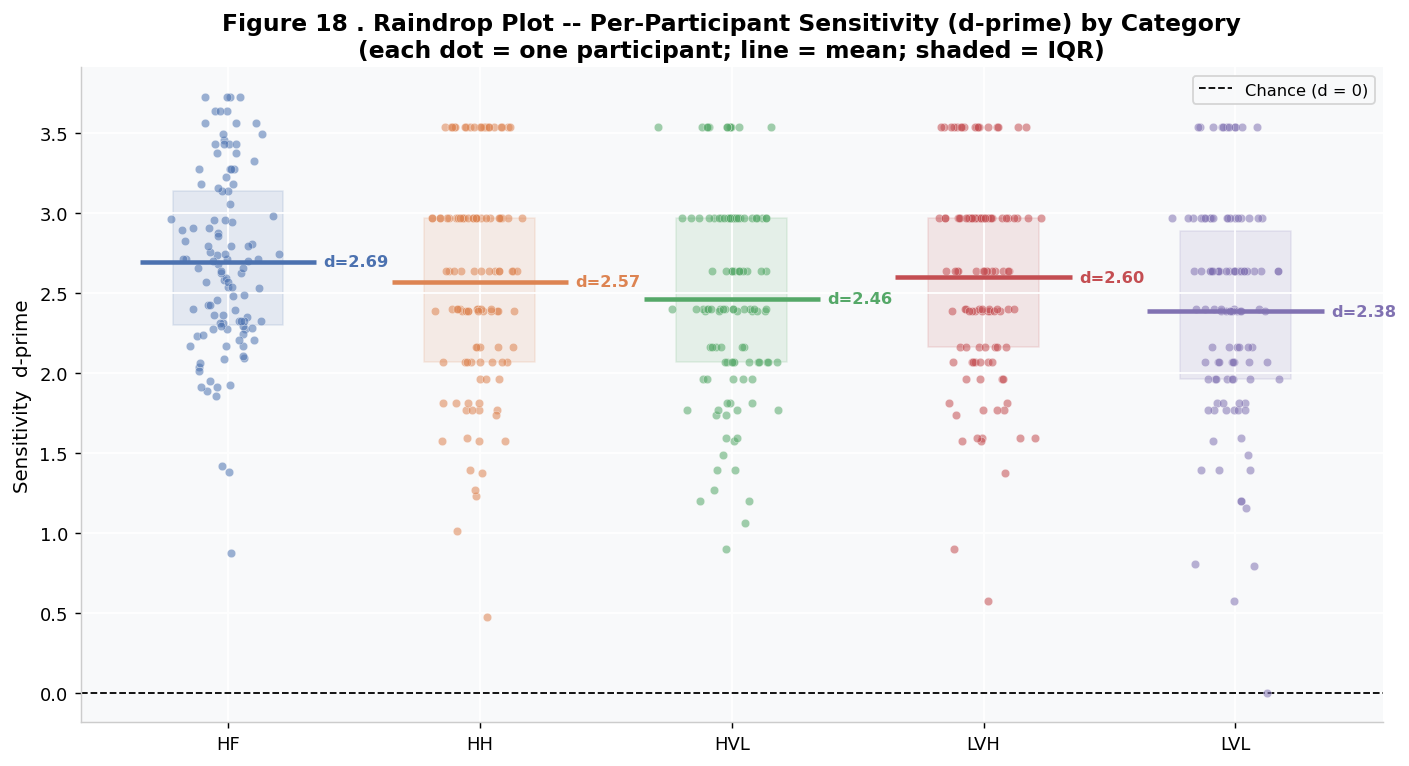

In [90]:
# -- Figure 18 . Raindrop Plot -- per-participant d-prime broken down by category

from scipy.stats import norm as _norm

def sdt_metrics_safe(sub):
    # Compute d-prime; return NaN row when sub-group is too sparse
    hits  = sub['outcome'].eq('Hit').sum()
    miss  = sub['outcome'].eq('Miss').sum()
    fa    = sub['outcome'].eq('False Alarm').sum()
    cr    = sub['outcome'].eq('Correct Reject').sum()
    n_sig = hits + miss
    n_nos = fa   + cr
    if n_sig == 0 or n_nos == 0:
        return pd.Series({'hit_rate': np.nan, 'fa_rate': np.nan,
                           'd_prime':  np.nan, 'criterion': np.nan})
    # Log-linear correction to avoid ppf(0) and ppf(1)
    hit_r_c = (hits + 0.5) / (n_sig + 1)
    fa_r_c  = (fa   + 0.5) / (n_nos + 1)
    zh = _norm.ppf(np.clip(hit_r_c, 1e-6, 1 - 1e-6))
    zf = _norm.ppf(np.clip(fa_r_c,  1e-6, 1 - 1e-6))
    return pd.Series({
        'hit_rate':  hits / n_sig,
        'fa_rate':   fa   / n_nos,
        'd_prime':   zh - zf,
        'criterion': -0.5 * (zh + zf),
    })

# include_groups=False required for pandas >= 2.2
try:
    per_ppt_cat = (
        trial_df.groupby(['participant', 'category'])
        .apply(sdt_metrics_safe, include_groups=False)
        .reset_index()
    )
except TypeError:
    per_ppt_cat = (
        trial_df.groupby(['participant', 'category'])
        .apply(sdt_metrics_safe)
        .reset_index()
    )

per_ppt_cat = per_ppt_cat.dropna(subset=['d_prime'])
print(f"Rows after dropping NaN d-prime: {len(per_ppt_cat)}")

# -- Raindrop plot
fig, ax = plt.subplots(figsize=(11, 6))
rng = np.random.default_rng(7)

for i, cat in enumerate(CATS):
    vals = per_ppt_cat[per_ppt_cat.category == cat]['d_prime'].dropna().values
    if len(vals) == 0:
        continue
    jitter = rng.normal(0, 0.09, size=len(vals))
    ax.scatter(jitter + i, vals, s=22, alpha=0.55,
               color=CAT_PALETTE[cat], edgecolors='white', linewidths=0.3, zorder=3)
    mn = vals.mean()
    ax.hlines(mn, i - 0.35, i + 0.35, colors=CAT_PALETTE[cat],
              linewidths=2.5, zorder=4)
    ax.text(i + 0.38, mn, f'd={mn:.2f}', va='center', fontsize=9,
            fontweight='bold', color=CAT_PALETTE[cat])
    q1, q3 = np.percentile(vals, 25), np.percentile(vals, 75)
    ax.fill_between([i - 0.22, i + 0.22], q1, q3,
                    color=CAT_PALETTE[cat], alpha=0.12, zorder=1)

ax.axhline(0, color='black', linewidth=1, linestyle='--', label='Chance (d = 0)')
ax.set_xticks(range(len(CATS)))
ax.set_xticklabels(CATS, fontsize=10)
ax.set_ylabel('Sensitivity  d-prime', fontsize=11)
ax.set_title(
    'Figure 18 . Raindrop Plot -- Per-Participant Sensitivity (d-prime) by Category\n'
    '(each dot = one participant; line = mean; shaded = IQR)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig18_raindrop_dprime.png', bbox_inches='tight')
plt.show()


---
## 11 · Temporal & Flow Visualizations

> **Goal:** How do outcomes evolve across the experiment? What does the processing pipeline look like from first presentation to correct word recognition?


In [92]:

# # ── Figure 20 · Streamgraph — outcome proportions across trial blocks ───────
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.ndimage import gaussian_filter1d

# # Bin trial index into blocks of 10
# trial_df["trial_block"] = (trial_df["trial_index"] // 10) * 10
# block_prop = (
#     trial_df.groupby(["trial_block","outcome"]).size()
#     .unstack(fill_value=0)
#     .apply(lambda r: r/r.sum(), axis=1)
# )
# block_prop = block_prop.reindex(columns=["Correct Reject","Miss","False Alarm","Hit"])
# block_prop = block_prop[block_prop.index <= 200]
# x = block_prop.index.values

# # Smooth each stream
# sigma = 2
# smoothed = {col: gaussian_filter1d(block_prop[col].values, sigma=sigma)
#             for col in block_prop.columns}

# # Streamgraph: stack with symmetric baseline (Wiggle baseline)
# ys = np.array([smoothed[col] for col in block_prop.columns])  # (4, T)
# T  = ys.shape[1]
# baseline = -0.5 * ys.sum(axis=0)   # symmetric / wiggle

# fig, ax = plt.subplots(figsize=(12, 6))
# ax.set_facecolor("#0d1117"); fig.patch.set_facecolor("#0d1117")
# stream_colors = [OUT_PALETTE[c] for c in block_prop.columns]

# bottoms = baseline.copy()
# polys = []
# for i, (col, color) in enumerate(zip(block_prop.columns, stream_colors)):
#     tops = bottoms + ys[i]
#     ax.fill_between(x, bottoms, tops, color=color, alpha=0.82, label=col, linewidth=0)
#     ax.plot(x, tops,   color="white", linewidth=0.4, alpha=0.4)
#     ax.plot(x, bottoms, color="white", linewidth=0.4, alpha=0.4)
#     # Mid-stream label at peak
#     mid_t = x[np.argmax(ys[i])]
#     mid_y = bottoms[np.argmax(ys[i])] + ys[i].max()/2
#     ax.text(mid_t, mid_y, col, ha="center", va="center",
#             fontsize=8.5, color="white", fontweight="bold", alpha=0.9)
#     bottoms = tops

# ax.set_xlabel("Trial Block (binned by 10)", fontsize=11, color="white")
# ax.set_ylabel("Proportion (symmetric baseline)", fontsize=11, color="white")
# ax.set_title("Figure 20 · Streamgraph — Trial Outcome Proportions Over the Experiment",
#              fontsize=13, fontweight="bold", color="white")
# ax.tick_params(colors="white")
# ax.spines["bottom"].set_color("white"); ax.spines["left"].set_color("white")
# for sp in ["top","right"]: ax.spines[sp].set_visible(False)
# ax.legend(loc="upper right", fontsize=9,
#           facecolor="#1a1a2e", labelcolor="white", framealpha=0.8)
# plt.tight_layout()
# plt.savefig("fig20_streamgraph.png", bbox_inches="tight", facecolor="#0d1117")
# plt.show()


---
## 12 · Cross-Metric Deep Dive — Histograms & Box-Plots

> Paired **histogram + KDE** and **box-plot** panels to examine the shape of each core distribution, identify skew, outliers, and compare conditions statistically.


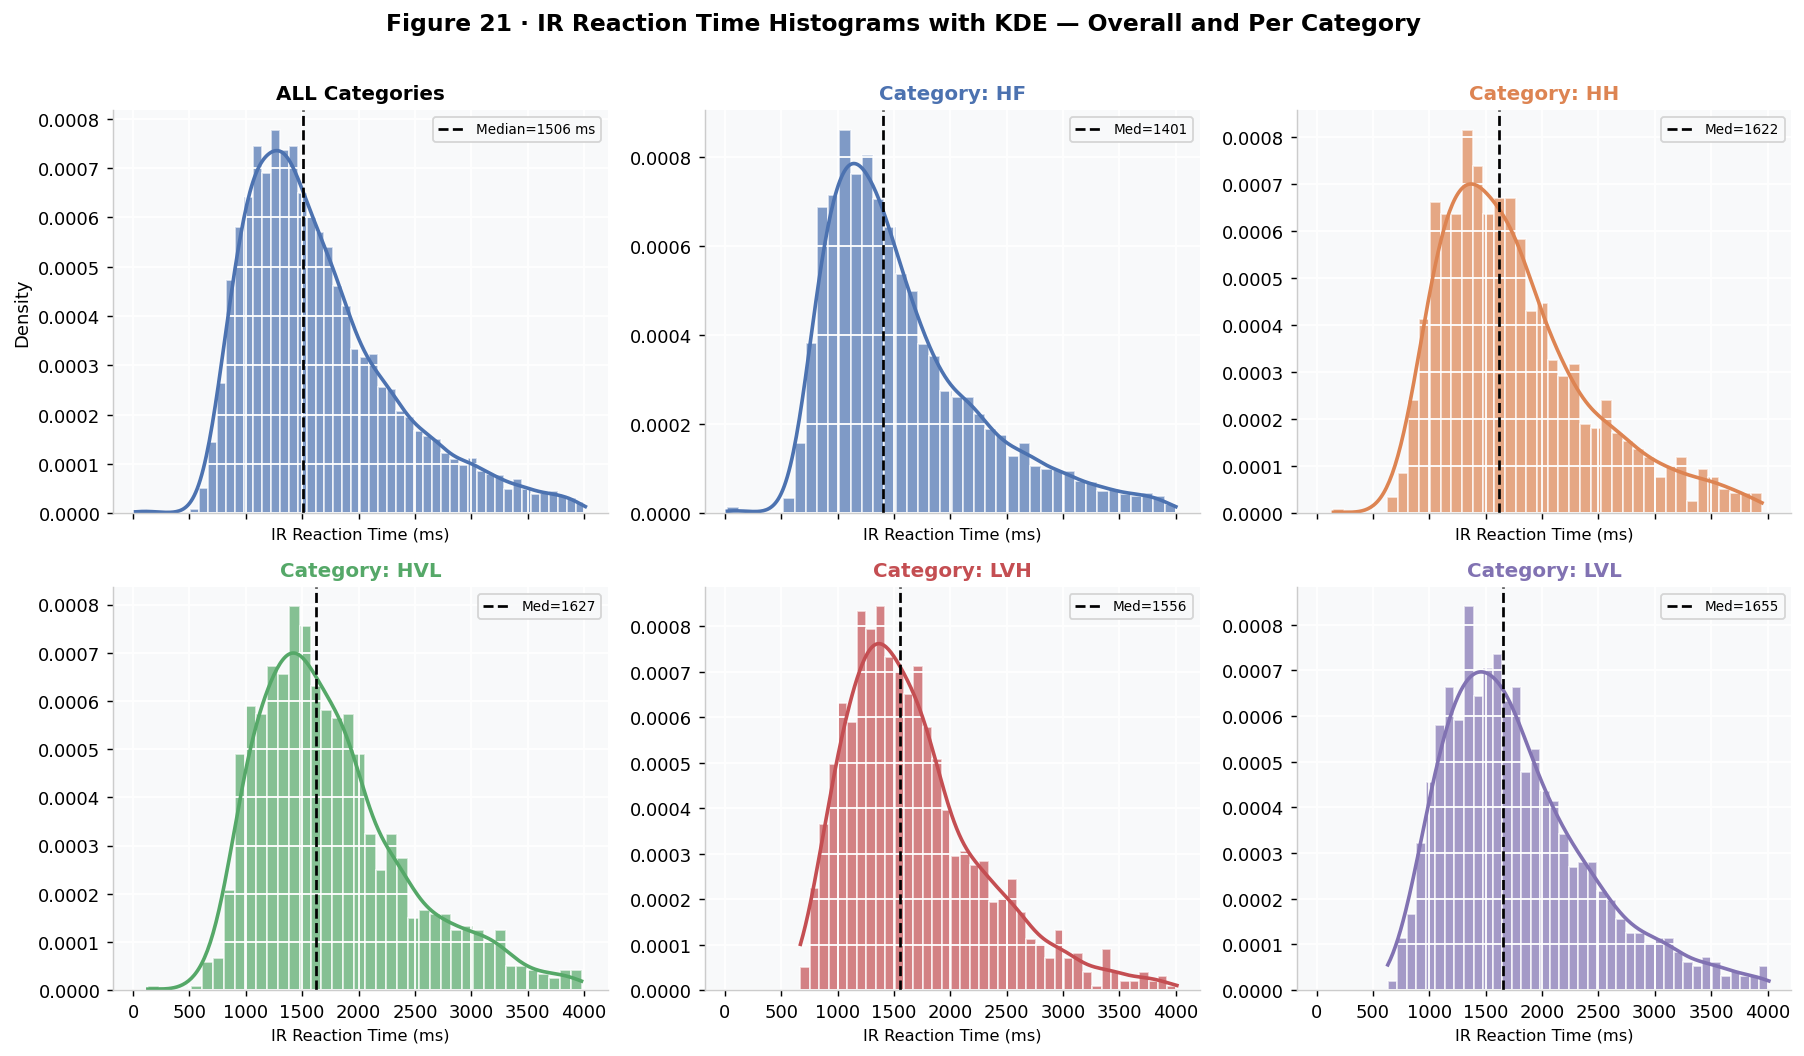

In [93]:

# ── Figure 21 · Histogram Grid — IR reaction time per category ─────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=False)
axes = axes.flatten()

rt_clip = 5000   # ms

# Overall in first panel
ax = axes[0]
data = trial_df["rt_ir"].dropna().clip(upper=rt_clip)
ax.hist(data, bins=50, color=BLUE, alpha=0.7, edgecolor="white", density=True)
from scipy.stats import gaussian_kde
kde = gaussian_kde(data, bw_method="scott")
xs  = np.linspace(data.min(), data.max(), 300)
ax.plot(xs, kde(xs), color=BLUE, linewidth=2)
ax.axvline(data.median(), color="black", linestyle="--", linewidth=1.5,
           label=f"Median={data.median():.0f} ms")
ax.set_title("ALL Categories", fontsize=11, fontweight="bold")
ax.legend(fontsize=7.5); ax.set_ylabel("Density", fontsize=10)

for i, cat in enumerate(CATS):
    ax = axes[i+1]
    data = trial_df[trial_df.category==cat]["rt_ir"].dropna().clip(upper=rt_clip)
    ax.hist(data, bins=40, color=CAT_PALETTE[cat], alpha=0.7, edgecolor="white", density=True)
    kde = gaussian_kde(data, bw_method="scott")
    xs  = np.linspace(data.min(), data.max(), 300)
    ax.plot(xs, kde(xs), color=CAT_PALETTE[cat], linewidth=2)
    ax.axvline(data.median(), color="black", linestyle="--", linewidth=1.5,
               label=f"Med={data.median():.0f}")
    ax.set_title(f"Category: {cat}", fontsize=11, fontweight="bold", color=CAT_PALETTE[cat])
    ax.legend(fontsize=7.5)

for ax in axes:
    ax.set_xlabel("IR Reaction Time (ms)", fontsize=9)

fig.suptitle("Figure 21 · IR Reaction Time Histograms with KDE — Overall and Per Category",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig21_rt_histograms.png", bbox_inches="tight")
plt.show()


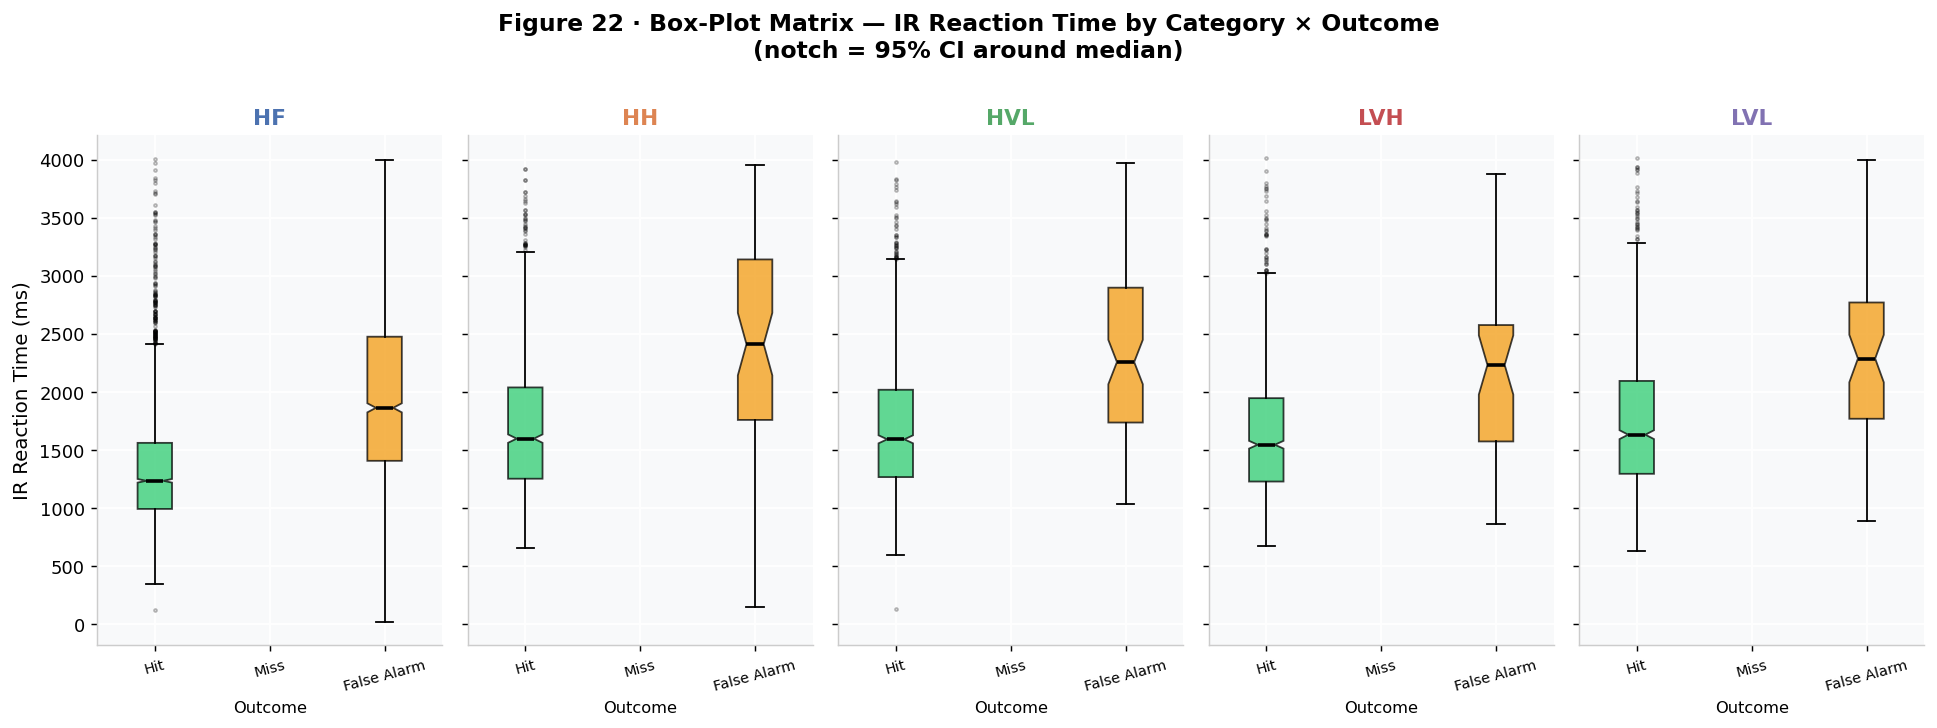

In [94]:

# ── Figure 22 · Box-Plot Matrix — RT by Category and Outcome ──────────────
import matplotlib.pyplot as plt
import numpy as np

ir_subset = trial_df[trial_df.outcome.isin(["Hit","Miss","False Alarm"]) & trial_df["rt_ir"].notna()]

fig, axes = plt.subplots(1, len(CATS), figsize=(15, 5.5), sharey=True)

outcomes_sub = ["Hit","Miss","False Alarm"]
colors_sub   = [OUT_PALETTE[o] for o in outcomes_sub]

for ax, cat in zip(axes, CATS):
    data_per_out = [ir_subset[(ir_subset.category==cat) & (ir_subset.outcome==o)]["rt_ir"].dropna()
                   for o in outcomes_sub]
    bp = ax.boxplot(data_per_out, patch_artist=True, notch=True,
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker=".", markersize=3, alpha=0.3))
    for patch, color in zip(bp["boxes"], colors_sub):
        patch.set_facecolor(color); patch.set_alpha(0.75)

    ax.set_xticks(range(1, len(outcomes_sub)+1))
    ax.set_xticklabels(outcomes_sub, fontsize=8, rotation=15)
    ax.set_title(cat, fontsize=12, fontweight="bold", color=CAT_PALETTE[cat])
    ax.set_xlabel("Outcome", fontsize=9)

axes[0].set_ylabel("IR Reaction Time (ms)", fontsize=11)

fig.suptitle("Figure 22 · Box-Plot Matrix — IR Reaction Time by Category × Outcome\n"
             "(notch = 95% CI around median)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig22_boxplot_matrix.png", bbox_inches="tight")
plt.show()
